## Two-Link Planar Robot Jacobian

<img src="https://faculty.gvsu.edu/kraussry/445_images/learning_activities/jacobians/two_link_planar.png" width=400px>

## Problem Statement

- find the singularity conditions for the two-link planar robot show above

## Steps:

- Find a symbolic expression for the velocity of the tip of the robot using `sympy`.
- Take partial derivatives of $\bar{v}_{tip}$ to find the Jacobian of the robot.
- Take the determinant of your Jacobian to find the singularity conditions

In [46]:
import sympy
from sympy.interactive import printing
printing.init_printing(use_latex=True)
import robotics_sympy

## Properly defining nice looking symbols

In [47]:
th1, th1dot, th2, th2dot, L1, L2 = sympy.symbols(['\\theta_1','\\dot{\\theta}_1','\\theta_2','\\dot{\\theta}_2','L_1','L_2'])

In [48]:
th1

In [49]:
th1dot

 From eqn. 5.46:
 
 $$^iv_{i+1} = \; ^iv_i + ^i\omega_i \times ^iP_{i+1}$$

### Step 1: finding $^1v_2$

Find the velocity of the end of link 1
- $O_2$ is at the connection point between the end of link 1 and the base of link 2

$$^1v_{2} = \; ^1v_1 + ^1\omega_{1} \times  ^1P_{2}$$

The velocity of $O_1$ is referred to as $^1v_1$:

`sympy.Matrix` takes a list of rows as its input:

In [50]:
v1f1 = sympy.Matrix([[0],[0],[0]])
v1f1

$^1\omega_1$:

- the rotational velocity of link 1 in frame 1:

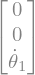

In [51]:
w1f1 = sympy.Matrix([[0],[0],[th1dot]])
w1f1

$^1P_2$:

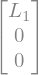

In [52]:
P2f1 = sympy.Matrix([[L1],[0],[0]])
P2f1

$^1v_2$:

$$^1v_{2} = \; ^1v_1 + ^1\omega_{1} \times  ^1P_{2}$$

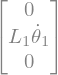

In [53]:
v2f1 = v1f1 + w1f1.cross(P2f1)
v2f1

<img src="https://faculty.gvsu.edu/kraussry/445_images/lecture_slides_images_445/class_17/class_17_jacobians_part_2_markedup_0008.jpg" width=800px>

### Step 2: finding $^2v_{tip}$


$$^2v_{tip} = \; ^2v_{3} = \; ^2v_2 + ^2\bar{\omega}_{2} \times ^2P_{3}$$

$^2v_2$:

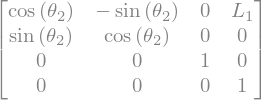

In [13]:
T12 = robotics_sympy.DH(0,L1,th2,0)
T12

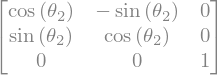

In [14]:
R12 = T12[0:3,0:3]
R12

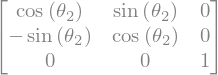

In [15]:
R21 = R12.T
R21

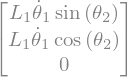

In [17]:
v2f2 = R21@v2f1
v2f2

$^2v_{tip} = \; ^2v_3$:

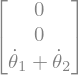

In [19]:
w2f2 = R21@w1f1 + sympy.Matrix([[0],[0],[th2dot]])
w2f2

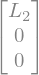

In [21]:
P3f2 = sympy.Matrix([[L2],[0],[0]])
P3f2

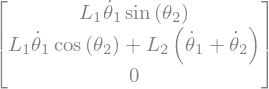

In [34]:
vtipf2 = v2f2 + w2f2.cross(P3f2)
vtipf2

<img src="https://faculty.gvsu.edu/kraussry/445_images/lecture_slides_images_445/class_17/class_17_jacobians_part_2_markedup_0010.jpg" width=800px>

### Step 3: take partial derivatives to find $\mathbf{J}$

$$\mathbf{J} = \begin{bmatrix} \displaystyle \frac{\partial v_{tipx}}{\partial \dot{\theta}_1} & \displaystyle \frac{\partial v_{tipx}}{\partial \dot{\theta}_2} \\ \displaystyle \frac{\partial v_{tipy}}{\partial \dot{\theta}_1} & \displaystyle  \frac{\partial v_{tipy}}{\partial \dot{\theta}_2}   \end{bmatrix}$$

In [24]:
vtipx = vtipf2[0]
vtipx

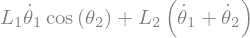

In [25]:
vtipy = vtipf2[1]
vtipy

In [26]:
J00 = vtipx.diff(th1dot)
J00

In [29]:
J01 = vtipx.diff(th2dot)
J01

In [30]:
J10 = vtipy.diff(th1dot)
J10

In [31]:
J11 = vtipy.diff(th2dot)
J11

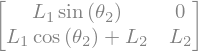

In [32]:
J = sympy.Matrix([[J00,J01],[J10,J11]])
J

###  Step 4: take the determinant to find the singularity conditions

$$\|\mathbf{J}\| = 0$$

In [33]:
det_J = J.det()
det_J

<img src="https://faculty.gvsu.edu/kraussry/445_images/lecture_slides_images_445/class_17/class_17_jacobians_part_2_markedup_0011.jpg" width=800px>